本地运行, 仅作查看数据使用

本记事本命名为op是因为multi和cite数据集的文件名以op开头...

multiome(Multiome) 用于从dna到rna预测
cite(CITEseq) 用于从rna到蛋白质预测

In [1]:
import os
os.chdir("../")
os.getcwd()

'd:\\desktop\\code\\conditional-flow-matching'

In [3]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

import warnings

# 忽略所有警告
warnings.filterwarnings("ignore")

# savedir = "models/single-cell"
# os.makedirs(savedir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


先查看预处理过的数据

In [4]:
# eb
eb = sc.read_h5ad("runner\data\Processed Single-cell RNA Time Series DAta\ebdata_v3.h5ad")
eb

AnnData object with n_obs × n_vars = 18203 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
eb.obs['sample_labels']

AAACATTGAAAGCA-1_Day 00-03    Day 00-03
AAACCGTGCAGAAA-1_Day 00-03    Day 00-03
AAACCGTGGAAGGC-1_Day 00-03    Day 00-03
AAACGCACCGGTAT-1_Day 00-03    Day 00-03
AAACGCACCTATTC-1_Day 00-03    Day 00-03
                                ...    
TTTCTACTCTTATC-1_Day 24-27    Day 24-27
TTTCTACTTGAGCT-1_Day 24-27    Day 24-27
TTTGCATGATGACC-1_Day 24-27    Day 24-27
TTTGCATGCACTCC-1_Day 24-27    Day 24-27
TTTGCATGTTCTTG-1_Day 24-27    Day 24-27
Name: sample_labels, Length: 18203, dtype: category
Categories (5, object): ['Day 00-03', 'Day 06-09', 'Day 12-15', 'Day 18-21', 'Day 24-27']

In [8]:
eb.obsm['X_umap']

array([[ 2.661137  ,  9.220984  ],
       [ 4.117761  , 12.844812  ],
       [-0.07301868,  6.0537314 ],
       ...,
       [13.715051  , -0.98529667],
       [ 9.179336  , 12.777305  ],
       [13.878841  ,  1.2694268 ]], dtype=float32)

尝试绘制umap图像

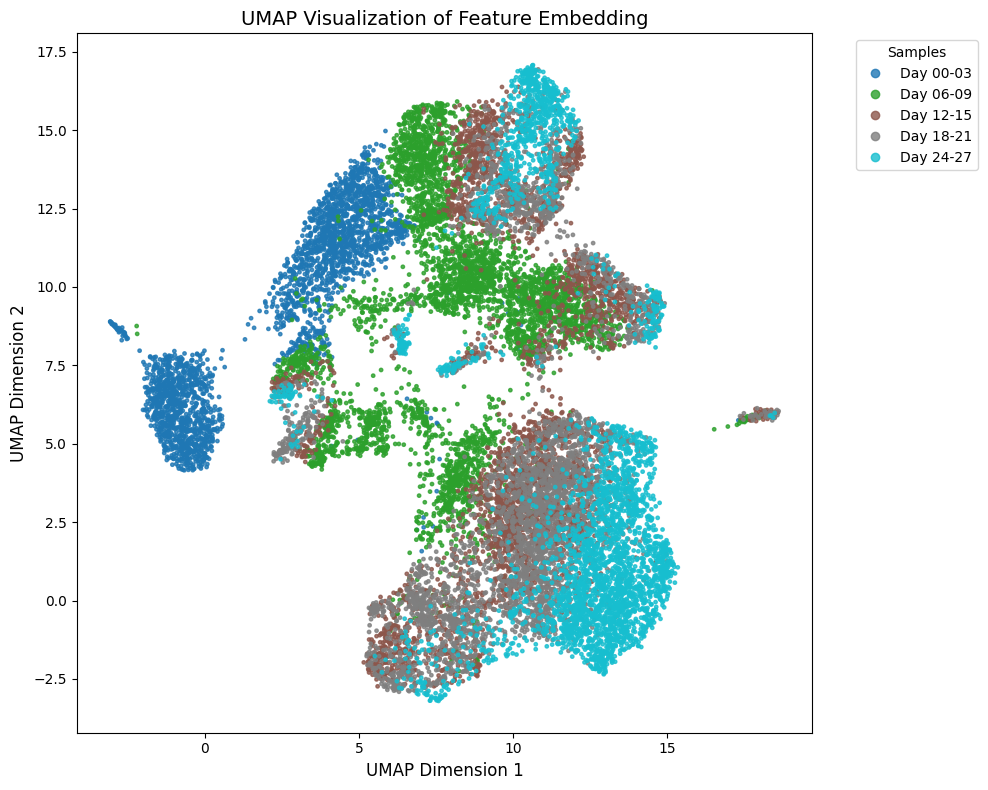

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 你的数据
umap_embedding = eb.obsm['X_umap']
labels = eb.obs['sample_labels']

# 关键：把类别转成数字
labels_num = labels.cat.codes

# 绘图
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    umap_embedding[:, 0], 
    umap_embedding[:, 1],
    c=labels_num,    # 必须用数字，不能用字符串
    cmap="tab10",
    s=6, alpha=0.8
)

# ✅ 修复在这里：转成 list 格式
plt.legend(
    handles=scatter.legend_elements()[0], 
    labels=list(labels.cat.categories),  # 这里加 list()
    title="Samples",
    bbox_to_anchor=(1.05, 1), loc="upper left"
)

plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.title("UMAP Visualization of Feature Embedding", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# multi
adata = sc.read_h5ad("runner\data\Processed Single-cell RNA Time Series DAta\op_train_multi_targets_0.h5ad")
adata

AnnData object with n_obs × n_vars = 33701 × 23418
    obs: 'day', 'donor', 'cell_type', 'technology'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [12]:
adata.obs["day"].unique()

array([2, 3, 4, 7], dtype=int64)

In [32]:
# cite
bdata = sc.read_h5ad("runner\data\Processed Single-cell RNA Time Series DAta\op_cite_inputs_0.h5ad")
bdata

AnnData object with n_obs × n_vars = 31240 × 22050
    obs: 'day', 'donor', 'cell_type', 'technology'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [12]:
bdata.obs['technology'].unique()

['citeseq']
Categories (1, object): ['citeseq']

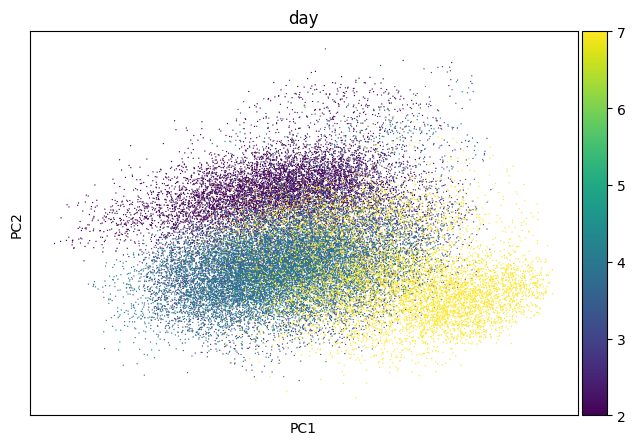

In [13]:
sc.pl.scatter(adata, basis="pca", color="day")

未经处理的数据, 来自竞赛网站

In [3]:
import h5py

In [4]:
import h5py

# 替换为你的文件路径（已解决转义问题）
path = r"runner\data\open-problems-multimodal\train_multi_inputs.h5"

# 递归打印H5文件所有层级的键和属性
def print_h5_structure(group, prefix=""):
    for key in group.keys():
        item = group[key]
        item_path = f"{prefix}/{key}" if prefix else key
        # 区分数据集（Dataset）和组（Group）
        if isinstance(item, h5py.Dataset):
            print(f"数据集：{item_path} | 形状：{item.shape} | 数据类型：{item.dtype}")
        elif isinstance(item, h5py.Group):
            print(f"组：{item_path}")
            print_h5_structure(item, prefix=item_path)

with h5py.File(path, "r") as f:
    print("===== H5文件完整结构 =====")
    print_h5_structure(f)

===== H5文件完整结构 =====
组：train_multi_inputs
数据集：train_multi_inputs/axis0 | 形状：(228942,) | 数据类型：|S26
数据集：train_multi_inputs/axis1 | 形状：(105942,) | 数据类型：|S12
数据集：train_multi_inputs/block0_items | 形状：(228942,) | 数据类型：|S26
数据集：train_multi_inputs/block0_values | 形状：(105942, 228942) | 数据类型：float32


In [ ]:
path = r"runner\data\open-problems-multimodal\train_multi_targets.h5"
with h5py.File(path, "r") as f:
    print("===== H5文件完整结构 =====")
    print_h5_structure(f)

===== H5文件完整结构 =====
组：train_multi_targets
数据集：train_multi_targets/axis0 | 形状：(23418,) | 数据类型：|S15
数据集：train_multi_targets/axis1 | 形状：(105942,) | 数据类型：|S12
数据集：train_multi_targets/block0_items | 形状：(23418,) | 数据类型：|S15
数据集：train_multi_targets/block0_values | 形状：(105942, 23418) | 数据类型：float32


In [7]:
path = r"runner\data\open-problems-multimodal\train_cite_inputs.h5"
with h5py.File(path, "r") as f:
    print("===== H5文件完整结构 =====")
    print_h5_structure(f)

===== H5文件完整结构 =====
组：train_cite_inputs
数据集：train_cite_inputs/axis0 | 形状：(22050,) | 数据类型：|S41
数据集：train_cite_inputs/axis1 | 形状：(70988,) | 数据类型：|S12
数据集：train_cite_inputs/block0_items | 形状：(22050,) | 数据类型：|S41
数据集：train_cite_inputs/block0_values | 形状：(70988, 22050) | 数据类型：float32


In [8]:
path = r"runner\data\open-problems-multimodal\train_cite_targets.h5"
with h5py.File(path, "r") as f:
    print("===== H5文件完整结构 =====")
    print_h5_structure(f)

===== H5文件完整结构 =====
组：train_cite_targets
数据集：train_cite_targets/axis0 | 形状：(140,) | 数据类型：|S11
数据集：train_cite_targets/axis1 | 形状：(70988,) | 数据类型：|S12
数据集：train_cite_targets/block0_items | 形状：(140,) | 数据类型：|S11
数据集：train_cite_targets/block0_values | 形状：(70988, 140) | 数据类型：float32


查看h5文件

In [28]:
import hdf5plugin
path = r"runner\data\open-problems-multimodal\train_multi_targets.h5"
try:
    with h5py.File(path, "r") as f:
        print("文件可正常打开，数据集列表：", list(f.keys()))
        print(f["train_multi_targets"]["axis1"][:])
        print(f["train_multi_targets"]["axis0"][:])
except Exception as e:
    print(f"文件损坏/无法读取：{e}")

文件可正常打开，数据集列表： ['train_multi_targets']
[b'56390cf1b95e' b'fc0c60183c33' b'9b4a87e22ad0' ... b'00783f28b463'
 b'e7abb1a0f251' b'193992d571a5']
[b'ENSG00000121410' b'ENSG00000268895' b'ENSG00000175899' ...
 b'ENSG00000162378' b'ENSG00000159840' b'ENSG00000074755']


In [ ]:
# 只需修改path
path = r"runner\data\open-problems-multimodal\train_multi_targets.h5"
with h5py.File(path, "r") as f:
    axis0_data = f['train_multi_targets/axis0'][:]
    print("axis0 (列名/特征名):")
    for i, name in enumerate(axis0_data):
        print(f"{i}: {name.decode('utf-8')}")
    print(f"总共 {len(axis0_data)} 个特征")

OSError: Can't synchronously read data (can't open directory)

In [16]:
import h5py

path = r"runner\data\open-problems-multimodal\train_multi_targets.h5"

# 先检查文件是否存在并查看完整结构
try:
    with h5py.File(path, "r") as f:
        print("===== H5文件完整结构 =====")
        def print_structure(name, obj):
            print(f"数据集：{name} | 形状：{obj.shape} | 数据类型：{obj.dtype}")
        
        f.visititems(print_structure)
except FileNotFoundError:
    print(f"文件未找到: {path}")
except Exception as e:
    print(f"读取文件时出错: {e}")

===== H5文件完整结构 =====
读取文件时出错: 'Group' object has no attribute 'shape'


In [6]:
n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
X = [
    adata.obsm["X_phate_standardized"][adata.obs["sample_labels"].cat.codes == t]
    for t in range(n_times)
]

NameError: name 'adata' is not defined

In [20]:
import h5py

# 读取少量标签和矩阵数据
path = r"runner\data\open-problems-multimodal\train_multi_targets.h5"
with h5py.File(path, "r") as f:
    # 读取前2个基因ID（axis1）和前2个细胞ID（axis0）
    gene_ids = f["train_multi_targets/axis1"][:2]  # 行标签：基因
    cell_ids = f["train_multi_targets/axis0"][:2]  # 列标签：细胞
    # 读取前2行（基因）× 前2列（细胞）的表达值
    expr_values = f["train_multi_targets/block0_values"][:2, :2]

print("前2个基因ID（axis1/行标签）：", [g.decode() for g in gene_ids])
print("前2个细胞ID（axis0/列标签）：", [c.decode() for c in cell_ids])
print("表达矩阵（行=基因，列=细胞）：")
print(expr_values)

OSError: Can't synchronously read data (can't open directory)

In [8]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

In [9]:
import scprep


def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata.obsm["X_phate_standardized"][:, 0],
        adata.obsm["X_phate_standardized"][:, 1],
        c=adata.obs["sample_labels"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with points from each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

## 1. OT-CFM
最优传输流匹配

In [10]:
for i in tqdm(range(10000)):
    ot_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    ot_cfm_optimizer.step()

100%|██████████| 10000/10000 [08:15<00:00, 20.19it/s]


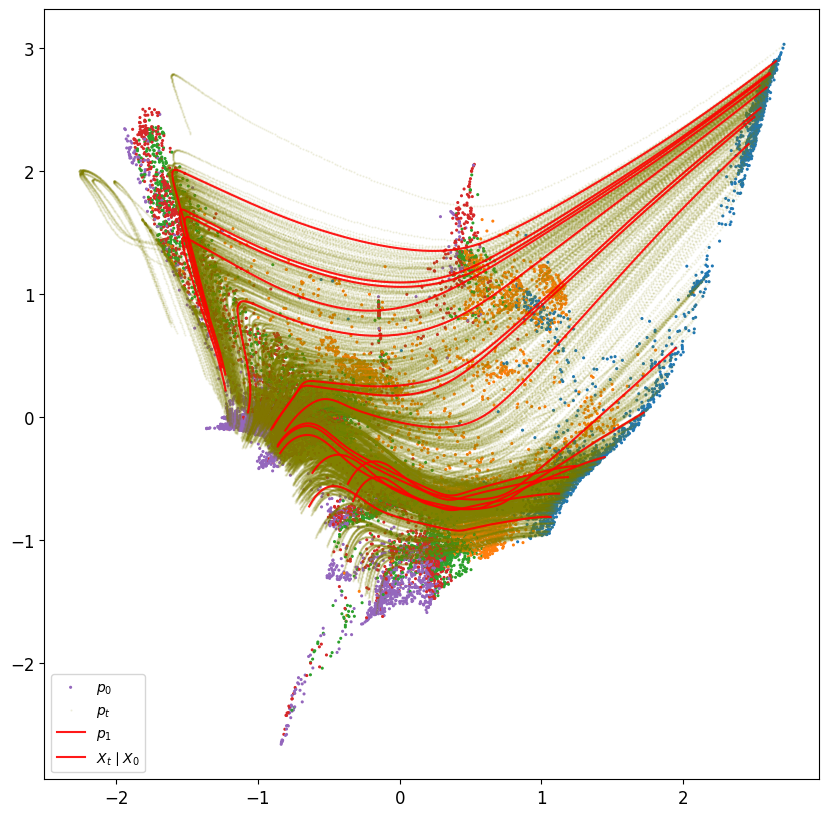

In [11]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [12]:
torch.save(
    {
        "model": ot_cfm_model,
        "optimizer": ot_cfm_optimizer,
    },
    f"{savedir}/ot_cfm_single_cell.pt",
)

## 2. SF2M
薛定谔桥条件流匹配

In [13]:
sigma = 0.25
sf2m_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_score_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_optimizer = torch.optim.AdamW(
    list(sf2m_model.parameters()) + list(sf2m_score_model.parameters()), 1e-4
)
SF2M = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)

In [14]:
max_norm_ut = torch.tensor(0.0)
for i in tqdm(range(10000)):
    sf2m_optimizer.zero_grad()
    t, xt, ut, eps = get_batch(SF2M, X, batch_size, n_times, return_noise=True)
    lambda_t = SF2M.compute_lambda(t % 1)
    vt = sf2m_model(torch.cat([xt, t[:, None]], dim=-1))
    st = sf2m_score_model(torch.cat([xt, t[:, None]], dim=-1))
    flow_loss = torch.mean((vt - ut) ** 2)
    # max_norm_ut = torch.maximum(torch.max(torch.sum(ut**2, dim=1)), max_norm_ut)
    score_loss = torch.mean((lambda_t[:, None] * st + eps) ** 2)
    if i % 1000 == 0:
        # print(max_norm_ut)
        
        print(f"iteration:{i}: flow_loss:{flow_loss.item():0.2f}, score_loss:{score_loss.item():0.2f}")
    loss = flow_loss + score_loss

    loss.backward()
    sf2m_optimizer.step()

  0%|          | 4/10000 [00:00<10:05, 16.51it/s]

iteration:0: flow_loss:1.11, score_loss:2.12


 10%|█         | 1003/10000 [00:51<07:41, 19.51it/s]

iteration:1000: flow_loss:0.32, score_loss:0.90


 20%|██        | 2003/10000 [01:43<06:52, 19.37it/s]

...

 80%|████████  | 8004/10000 [06:52<01:41, 19.72it/s]

iteration:8000: flow_loss:1.36, score_loss:0.81


 90%|█████████ | 9004/10000 [07:43<00:50, 19.57it/s]

iteration:9000: flow_loss:0.34, score_loss:0.82


100%|██████████| 10000/10000 [08:34<00:00, 19.43it/s]


In [15]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0.to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

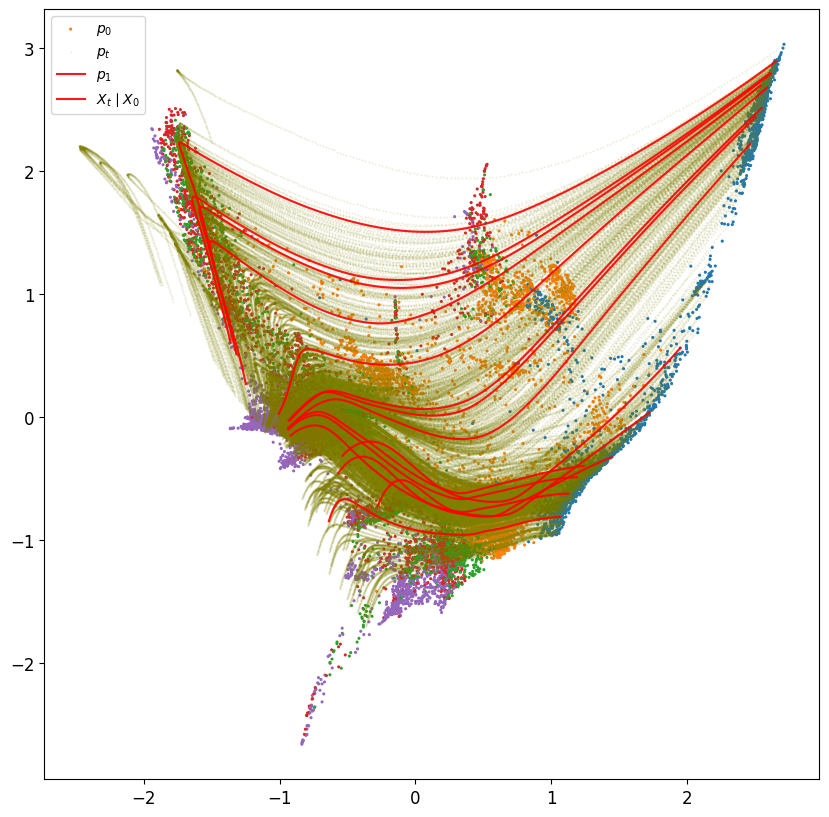

In [16]:
plot_trajectories(traj.cpu().numpy())

In [17]:
class SDE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, ode_drift, score, input_size=(3, 32, 32), sigma=1.0):
        super().__init__()
        self.drift = ode_drift
        self.score = score
        self.input_size = input_size
        self.sigma = sigma

    # Drift
    def f(self, t, y):
        y = y.view(-1, *self.input_size)
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        return self.drift(x).flatten(start_dim=1) + self.score(x).flatten(start_dim=1)

    # Diffusion
    def g(self, t, y):
        return torch.ones_like(y) * self.sigma


sde = SDE(sf2m_model, sf2m_score_model, input_size=(2,), sigma=sigma)
with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0.to(device),
        ts=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

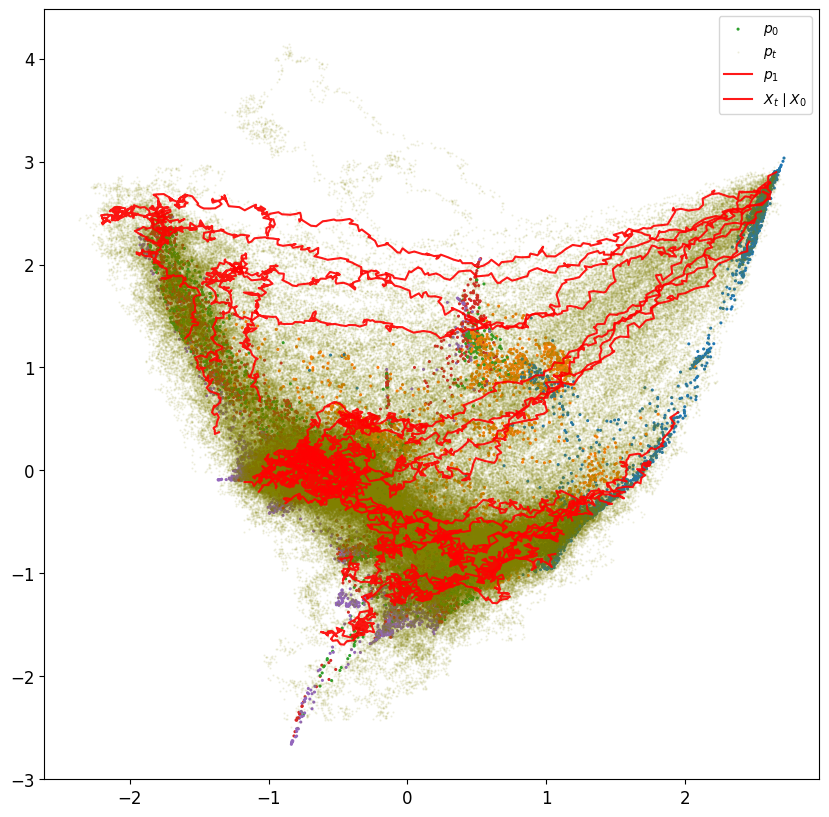

In [18]:
plot_trajectories(sde_traj.detach().cpu().numpy())

In [19]:
torch.save(
    {
        "model": sf2m_model,
        "score_model": sf2m_score_model,
        "optimizer": sf2m_optimizer,
    },
    f"{savedir}/sf2m_single_cell_sigma_{sigma}.pt",
)

## 3. 从高斯分布出发的CFM
3-5小节为本人增加的实验。
用TargetConditionalFlowMatcher采样

In [20]:
sigma = 0.1
dim = 2
gaussian_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
gaussian_cfm_optimizer = torch.optim.Adam(gaussian_cfm_model.parameters(), 1e-4)
FM = TargetConditionalFlowMatcher(sigma=sigma)

for i in tqdm(range(10000)):
    gaussian_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = gaussian_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    gaussian_cfm_optimizer.step()

100%|██████████| 10000/10000 [00:34<00:00, 292.81it/s]


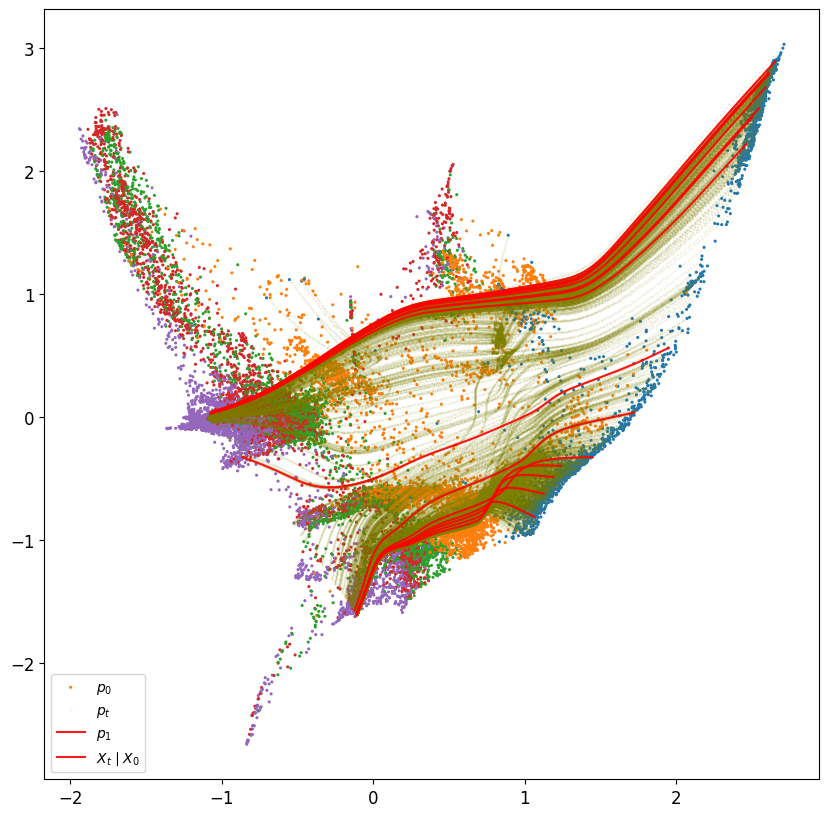

In [21]:
node = NeuralODE(torch_wrapper(gaussian_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [22]:
torch.save(
    {
        "model": gaussian_cfm_model,
        "optimizer": gaussian_cfm_optimizer,
    },
    f"{savedir}/gaussian_cfm_single_cell.pt",
)

## 4. I-CFM
用ConditionalFlowMatcher采样

In [23]:
sigma = 0.1
dim = 2
i_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
i_cfm_optimizer = torch.optim.Adam(i_cfm_model.parameters(), 1e-4)
FM = ConditionalFlowMatcher(sigma=sigma)

for i in tqdm(range(10000)):
    i_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = i_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    i_cfm_optimizer.step()

100%|██████████| 10000/10000 [00:31<00:00, 322.52it/s]


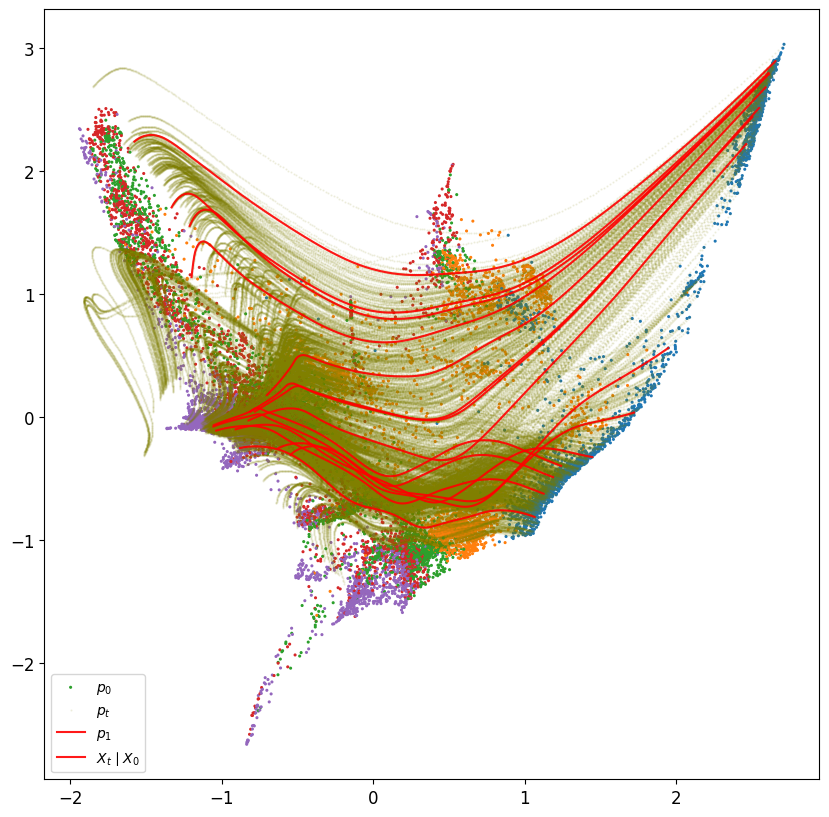

In [24]:
node = NeuralODE(torch_wrapper(i_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [25]:
torch.save(
    {
        "model": i_cfm_model,
        "optimizer": i_cfm_optimizer,
    },
    f"{savedir}/i_cfm_single_cell.pt",
)

## 5. 方差保留的CFM
用VariancePreservingConditionalFlowMatcher采样

In [26]:
sigma = 0.1
dim = 2
vp_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
vp_cfm_optimizer = torch.optim.Adam(vp_cfm_model.parameters(), 1e-4)
FM = VariancePreservingConditionalFlowMatcher(sigma=sigma)

for i in tqdm(range(10000)):
    vp_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = vp_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    vp_cfm_optimizer.step()

100%|██████████| 10000/10000 [00:35<00:00, 280.49it/s]


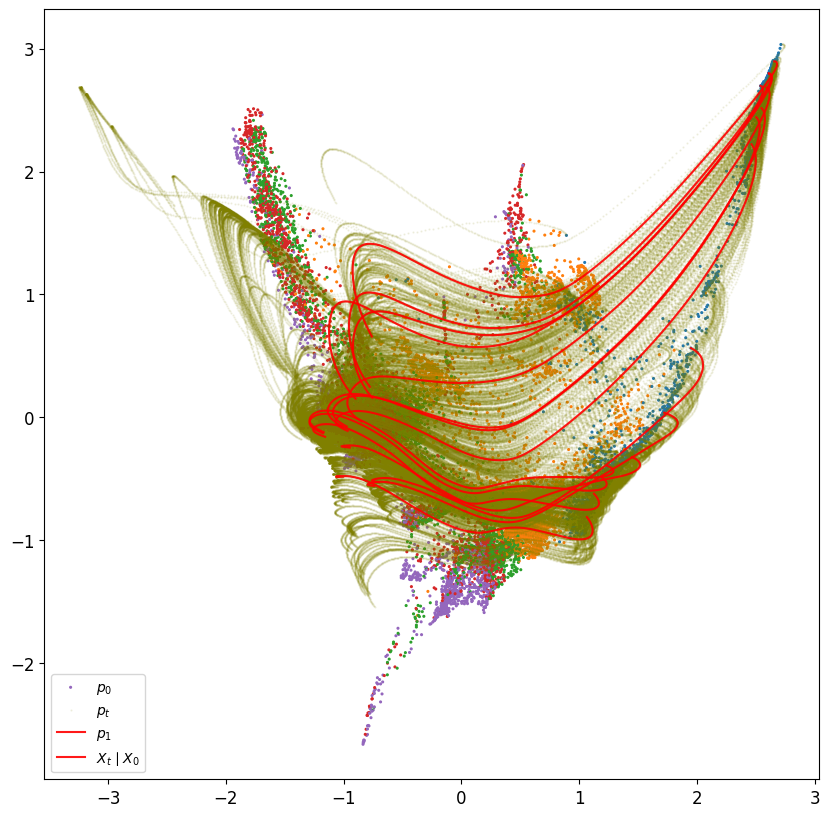

In [27]:
node = NeuralODE(torch_wrapper(vp_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [28]:
torch.save(
    {
        "model": vp_cfm_model,
        "optimizer": vp_cfm_optimizer,
    },
    f"{savedir}/vp_cfm_single_cell.pt",
)

# Evolution of trajectories between SF2M's probability flow ODE (SB-CFM) and SF2M

SB-CFM 与 SF2M 的轨迹演化
SB-CFM的轨迹是决定性的, 而SF2M是通过随机微分方程求解的

## Starting from a cell at day 0

In [29]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0[2].repeat(20).view(20, 2).to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()
# plot_trajectories(traj.cpu().numpy())

In [30]:
with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0[2].repeat(20).view(20, 2).to(device),
        ts=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

In [31]:
traj = traj.detach().cpu().numpy()
sde_traj = sde_traj.detach().cpu().numpy()

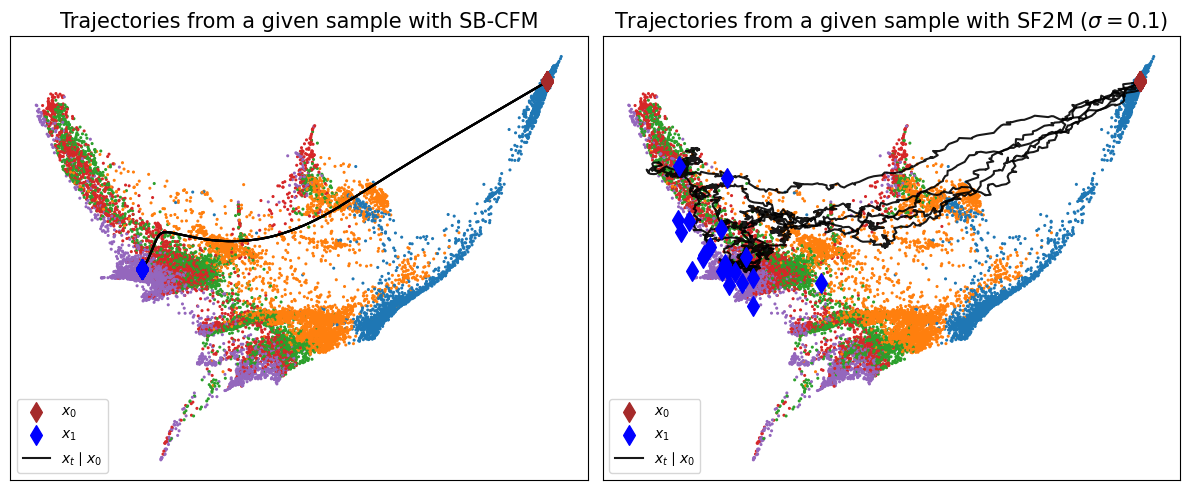

In [32]:
n = 2000
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(traj[0, :n, 0], traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3)
ax1.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3)

for i in range(5):
    ax1.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax1,
    legend=None,
)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Trajectories from a given sample with SB-CFM", fontsize=15)
ax1.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])


ax2.scatter(
    sde_traj[0, :n, 0], sde_traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3
)
ax2.scatter(
    sde_traj[-1, :n, 0], sde_traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3
)

for i in range(5):
    ax2.plot(sde_traj[:, i, 0], sde_traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax2,
    legend=None,
)

ax2.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(
    r"Trajectories from a given sample with SF2M $(\sigma={})$".format(sigma), fontsize=15
)

plt.tight_layout()
plt.savefig("conditonal_trajectory_sf2m_sigma_{}.png".format(sigma))

## Starting from a cell at an older time (day 25)

In [33]:
len(X)

5

In [34]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[1][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0[1].repeat(15).view(15, 2).to(device),
        t_span=torch.linspace(1, n_times - 1, 300, device=device),
    ).cpu()

with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0[1].repeat(15).view(15, 2).to(device),
        ts=torch.linspace(1, n_times - 1, 300, device=device),
    ).cpu()

traj = traj.detach().cpu().numpy()

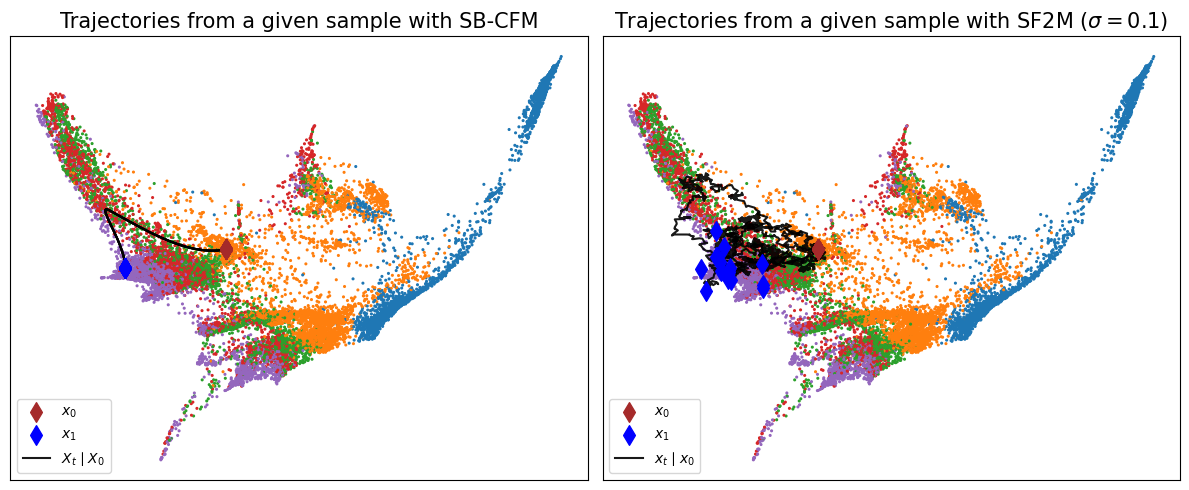

In [35]:
n = 2000
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.scatter(traj[0, :n, 0], traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3)
ax1.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3)

for i in range(5):
    ax1.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax1,
    legend=None,
)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Trajectories from a given sample with SB-CFM", fontsize=15)
ax1.legend([r"$x_0$", r"$x_1$", r"$X_t \mid X_0$"])


ax2.scatter(
    sde_traj[0, :n, 0], sde_traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3
)
ax2.scatter(
    sde_traj[-1, :n, 0], sde_traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3
)

for i in range(5):
    ax2.plot(sde_traj[:, i, 0], sde_traj[:, i, 1], alpha=0.9, c="black", zorder=2)


scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax2,
    legend=None,
)

ax2.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(
    r"Trajectories from a given sample with SF2M $(\sigma={})$".format(sigma), fontsize=15
)
# plt.axis("off")

plt.tight_layout()
plt.savefig("conditonal_trajectory_sf2m_sigma_{}_from_later_time.png".format(sigma))

### As SB-CFM is a deterministic process, it only ends up at one final location contrary to our model SF2M that models a stochastic process and produces different outputs.
由于 SB-CFM 是一个确定性过程，它最终只会到达一个固定的终点；而我们的模型 SF2M 则不同，它对随机过程进行建模，因此能产生多种不同的输出结果

In [1]:
import torch
import torchvision

# 1. 查看torch版本（核心）
print(f"PyTorch 版本: {torch.__version__}")

# 2. 查看torchvision版本
print(f"TorchVision 版本: {torchvision.__version__}")

# 3. 额外验证（可选，确认CUDA/环境）
print(f"CUDA 版本（torch内置）: {torch.version.cuda}")
print(f"当前设备GPU数量: {torch.cuda.device_count()}")
print(f"当前使用GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch 版本: 2.8.0+cpu
TorchVision 版本: 0.23.0+cpu
CUDA 版本（torch内置）: None
当前设备GPU数量: 0
当前使用GPU: CPU
